# Diabetes prediction dataset
## Detecting and Mitigating Bias in Healthcare ML Models
**Name:** Abdelkerim Ali Hassan

**ID:** GH1046256

**Course:** M515A Ethical Issues for AI

**Dataset:** [Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset)


**Sensitive Attributes:** Gender (Female, Male) and Age Group (Young <40, Middle 40–60, Senior >60)


## 1. Problem Statement

Diabetes is one of the fastest-growing chronic diseases globally, affecting over 400 million
people. Healthcare providers increasingly rely on machine learning models to predict diabetes
risk and prioritise early intervention. However, if these models are trained on historically
biased data, they can systematically underdiagnose or misclassify certain demographic groups leading to unequal access to treatment.

This project addresses the following business problem: **Can we build a diabetes prediction
model that is both accurate and fair across gender and age groups?**

**Why it matters:**
A biased model in a clinical setting can cause real harm a patient from an underserved
group who is incorrectly classified as non-diabetic may not receive timely intervention,
leading to preventable complications. For a healthcare company, this also creates legal and
reputational risk under anti-discrimination frameworks such as the EU AI Act.

**Data collection:**
The dataset contains 100,000 patient records with clinical indicators (BMI, HbA1c level,
blood glucose level, hypertension, heart disease, smoking history) and demographic attributes
(gender, age). It is sourced from Kaggle and represents a realistic electronic health record
scenario.

**ML formulation:**
Binary classification predict whether a patient is diabetic (1) or non-diabetic (0).
Three classifiers are trained: Logistic Regression, Random Forest, and Decision Tree.
Sensitive attributes: Gender and Age Group.

# Import Libraries

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Loading data

In [91]:
df = pd.read_csv('diabetes_prediction_dataset.csv', na_values=['?', ' ?'])
print("Shape:", df.shape)
display(df.head())

Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


**Basic structure**

In [92]:
print(df.shape)
print(df.dtypes)
print(df.head(10))

(100000, 9)
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   
5  Female  20.0             0              0           never  27.32   
6  Female  44.0             0              0           never  19.31   
7  Female  79.0             0              0         No Info  23.86   
8    Male  42.0             0              0           n

**Missing values**

In [93]:
print(df.isna().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


**Target distribution**

In [94]:
print(df['diabetes'].value_counts())
print(df['diabetes'].value_counts(normalize=True))

diabetes
0    91500
1     8500
Name: count, dtype: int64
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


**Target Variable Distribution (Bar and Pie Chart)**

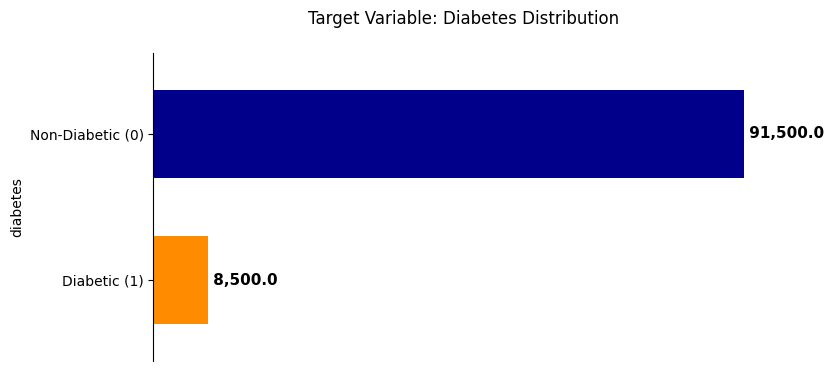

In [95]:
ax = df['diabetes'].value_counts(ascending=True).plot.barh(
    figsize=(8, 4), color=['darkorange', 'darkblue'], width=0.6,
    title='Target Variable: Diabetes Distribution\n'
)

ax.bar_label(ax.containers[0], fmt=' {:,}', fontsize=11, fontweight='bold')
ax.set_yticklabels(['Diabetic (1)', 'Non-Diabetic (0)'])
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.get_xaxis().set_visible(False)

plt.show()

**Gender distribution**

In [96]:
print(df['gender'].value_counts())

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64


**Diabetes rate by age group**

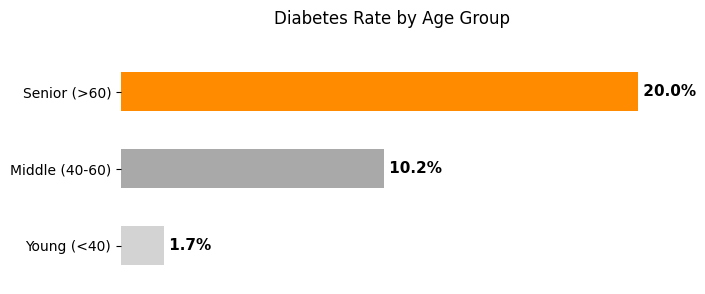

In [97]:
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 60, 120], labels=['Young (<40)', 'Middle (40-60)', 'Senior (>60)'])
ax = (df.groupby('age_group')['diabetes'].mean() * 100).plot.barh(figsize=(7, 3), color=['lightgray', 'darkgray', 'darkorange'], title='Diabetes Rate by Age Group\n')
ax.bar_label(ax.containers[0], fmt=' %.1f%%', fontweight='bold', fontsize=11)
ax.set(xticks=[], ylabel=''); ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

**Numerical feature distributions by class**

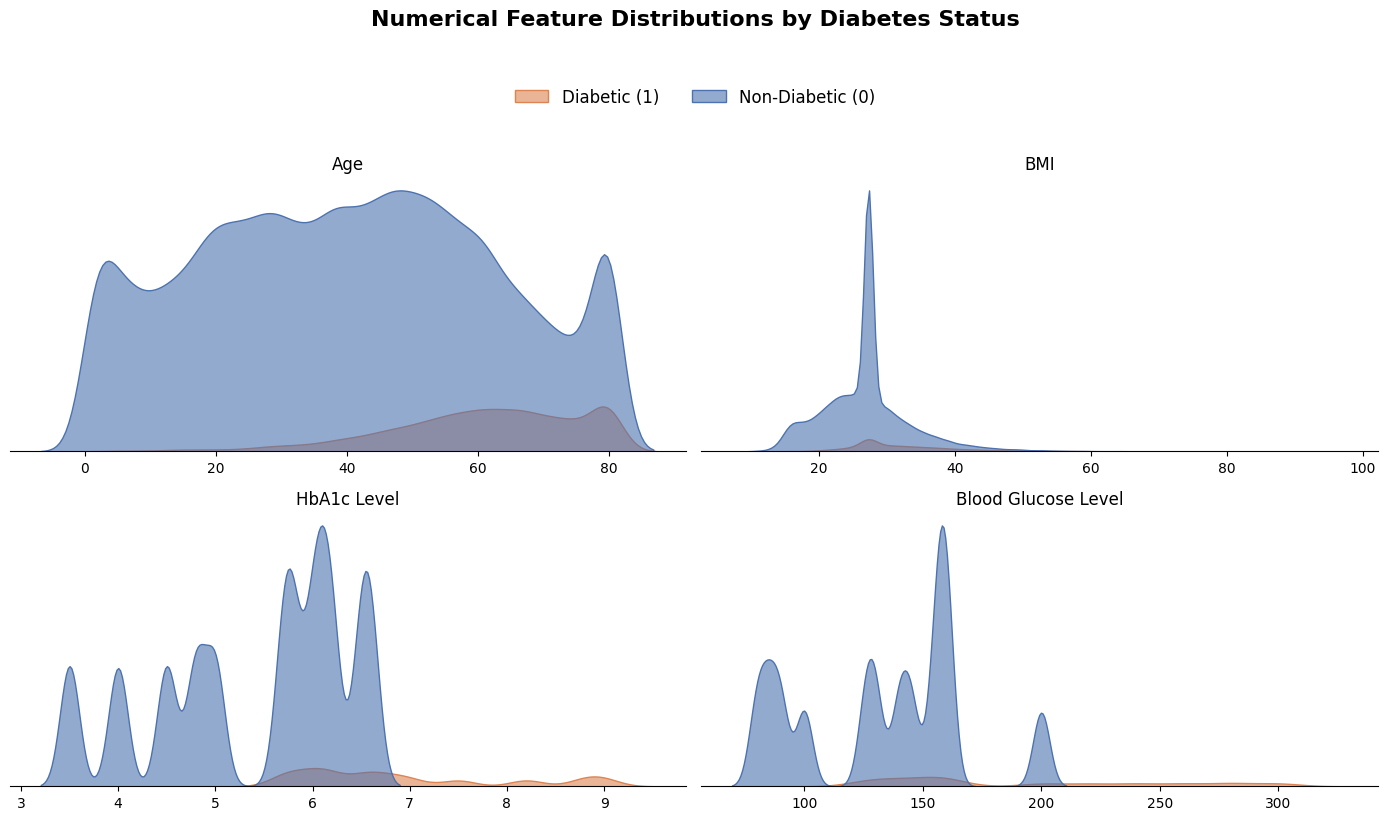

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
features = {'age': 'Age', 'bmi': 'BMI', 'HbA1c_level': 'HbA1c Level', 'blood_glucose_level': 'Blood Glucose Level'}

for ax, (col, title) in zip(axes.flatten(), features.items()):
    sns.kdeplot(data=df, x=col, hue='diabetes', fill=True, palette=['#4C72B0', '#DD8452'], alpha=0.6, ax=ax, legend=False)
    ax.set(title=title, xlabel='', ylabel='', yticks=[])
    ax.spines[['top', 'right', 'left']].set_visible(False)

fig.legend(['Diabetic (1)', 'Non-Diabetic (0)'], loc='upper center', bbox_to_anchor=(0.5, 0.94), ncol=2, frameon=False, fontsize=12)
plt.suptitle('Numerical Feature Distributions by Diabetes Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

**Diabetes rate per gender**

In [99]:
print(df.groupby('gender')['diabetes'].mean())

gender
Female    0.076189
Male      0.097490
Other     0.000000
Name: diabetes, dtype: float64


**Diabetes rate per age group**

In [100]:
df['age_group'] = pd.cut(df['age'], bins=[0,40,60,80], labels=['Young','Middle','Senior'])
print(df.groupby('age_group')['diabetes'].mean())

age_group
Young     0.016662
Middle    0.101709
Senior    0.199687
Name: diabetes, dtype: float64


# Preprocessing

In [101]:
df = df[df['gender'] != 'Other'].reset_index(drop=True)
df['gender_encoded'] = df['gender'].map({'Female': 0, 'Male': 1})
sensitive = df[['gender', 'age_group']].copy()

smoking_map = {'never': 0, 'No Info': 1, 'formerly': 2, 'ever': 3, 'not current': 4, 'current': 5}
df['smoking_encoded'] = df['smoking_history'].map(smoking_map).fillna(1)

feature_cols = ['gender_encoded', 'age', 'hypertension', 'heart_disease', 'smoking_encoded', 'bmi', 'HbA1c_level', 'blood_glucose_level']
X, y = df[feature_cols], df['diabetes']

print(f"Data Prepared successfully | X shape: {X.shape} | Total Missing Values: {X.isna().sum().sum()}")

Data Prepared successfully | X shape: (99982, 8) | Total Missing Values: 0


**Feature correlation heatmap**

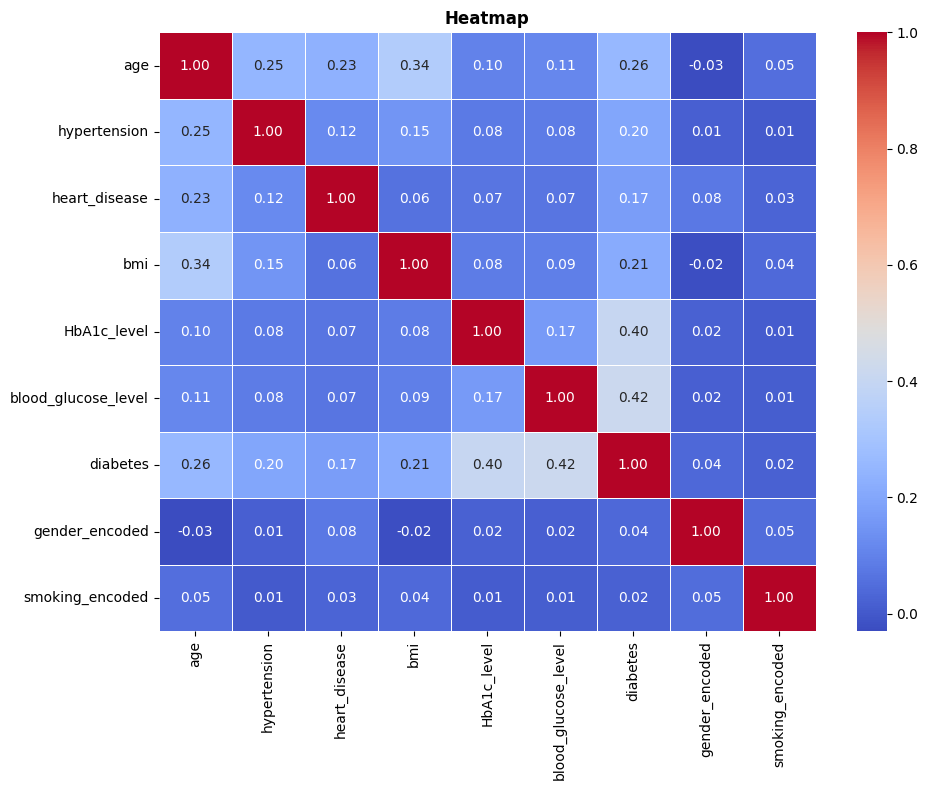

In [102]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

# Train/Test Split

In [103]:
X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X, y, sensitive,
    test_size=0.2,
    random_state=42,
    stratify=y
)

zero_variance_cols = X_train.columns[X_train.var() == 0]
if len(zero_variance_cols) > 0:
    print(f"Warning: Zero-variance columns found in X_train: {list(zero_variance_cols)}. These columns will be dropped before scaling to prevent NaN values.")
    X_train = X_train.drop(columns=zero_variance_cols)
    X_test = X_test.drop(columns=zero_variance_cols)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])
print("\nTest target distribution:")
print(y_test.value_counts())
print("\nTest gender distribution:")
print(sens_test['gender'].value_counts())
print("\nTest age group distribution:")
print(sens_test['age_group'].value_counts())

Train size: 79985
Test size:  19997

Test target distribution:
diabetes
0    18297
1     1700
Name: count, dtype: int64

Test gender distribution:
gender
Female    11662
Male       8335
Name: count, dtype: int64

Test age group distribution:
age_group
Young     9477
Middle    5818
Senior    4702
Name: count, dtype: int64


# Baseline Model Training

In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("\nRandom Forest:")
print(classification_report(y_test, y_pred_rf))
print("\nDecision Tree:")
print(classification_report(y_test, y_pred_dt))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18297
           1       0.88      0.64      0.74      1700

    accuracy                           0.96     19997
   macro avg       0.92      0.81      0.86     19997
weighted avg       0.96      0.96      0.96     19997


Random Forest:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18297
           1       0.94      0.69      0.80      1700

    accuracy                           0.97     19997
   macro avg       0.96      0.84      0.89     19997
weighted avg       0.97      0.97      0.97     19997


Decision Tree:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18297
           1       0.69      0.74      0.71      1700

    accuracy                           0.95     19997
   macro avg       0.83      0.85      0.84     19997
weighted avg       0.

**Model evaluation: Confusion matrices**

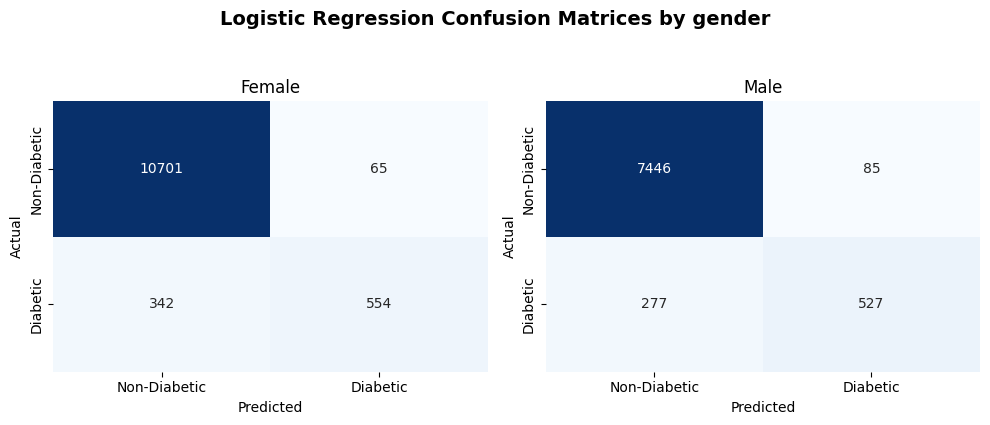

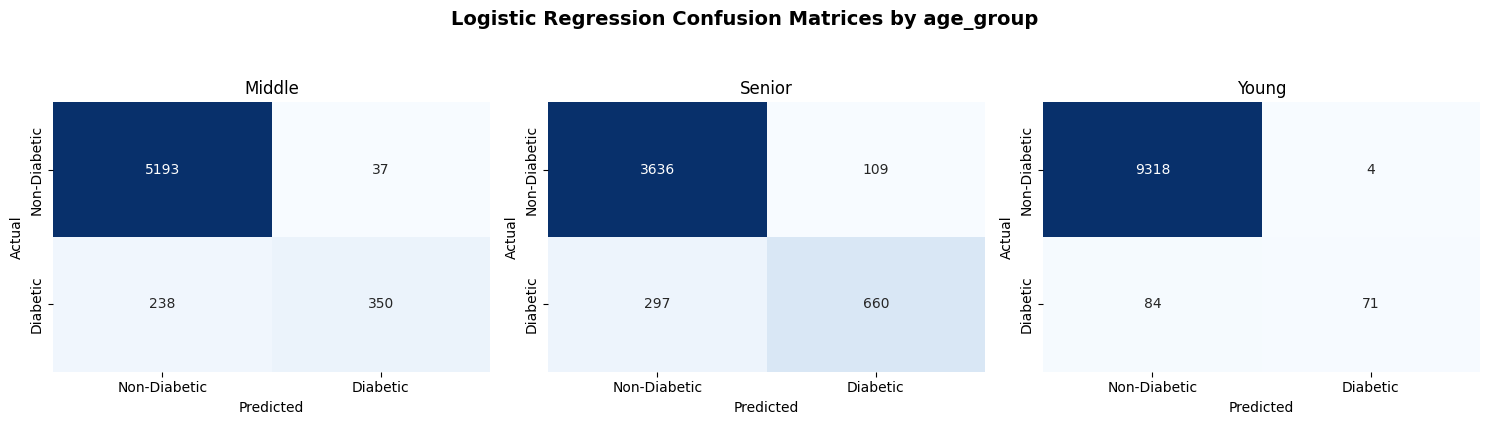

In [105]:
# Logistic Regression: Confusion Matrices by Gender and Age Group
y_pred_lr = lr.predict(X_test_scaled)
plot_subgroup_matrices(y_test.reset_index(drop=True), y_pred_lr, sens_test.reset_index(drop=True), 'gender', 'Logistic Regression')
plot_subgroup_matrices(y_test.reset_index(drop=True), y_pred_lr, sens_test.reset_index(drop=True), 'age_group', 'Logistic Regression')

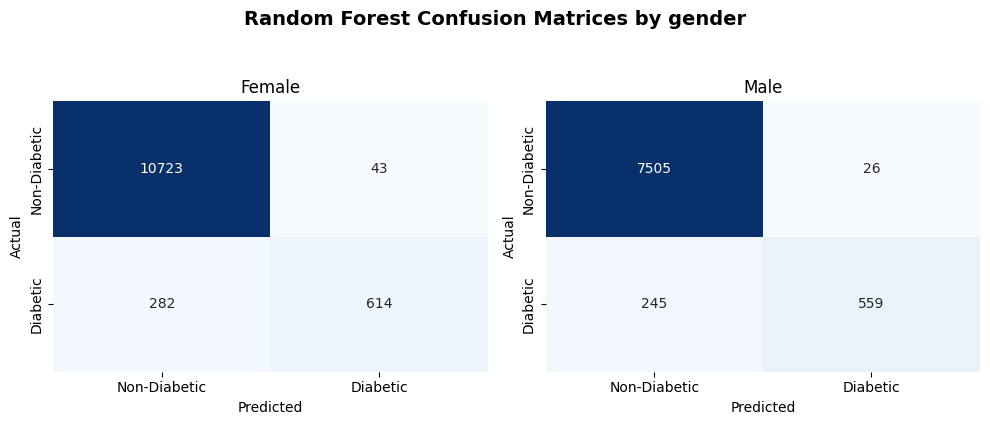

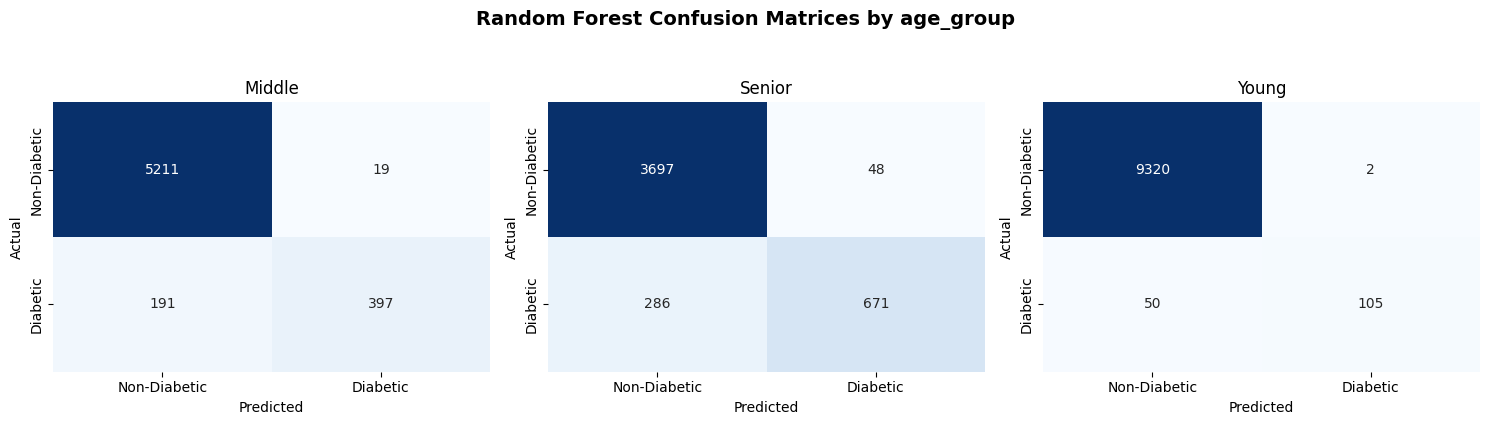

In [106]:
# Random Forest: Confusion Matrices by Gender and Age Group
y_pred_rf = rf.predict(X_test_scaled)
plot_subgroup_matrices(y_test.reset_index(drop=True), y_pred_rf, sens_test.reset_index(drop=True), 'gender', 'Random Forest')
plot_subgroup_matrices(y_test.reset_index(drop=True), y_pred_rf, sens_test.reset_index(drop=True), 'age_group', 'Random Forest')

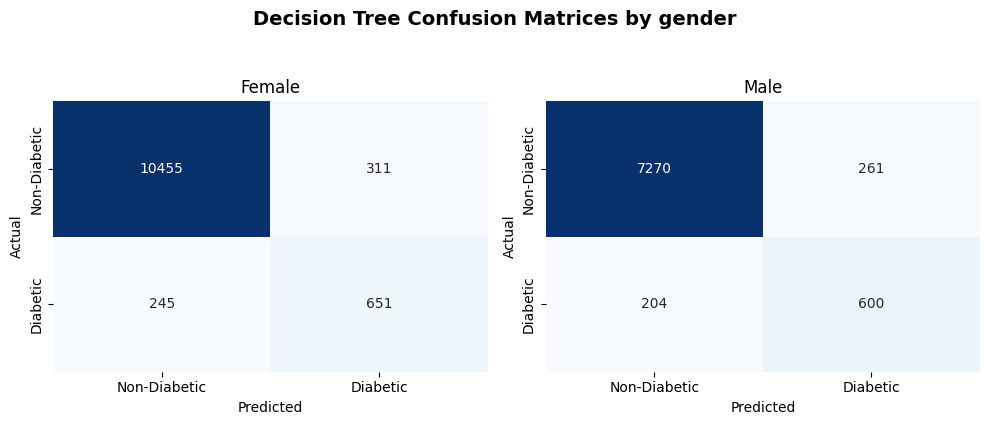

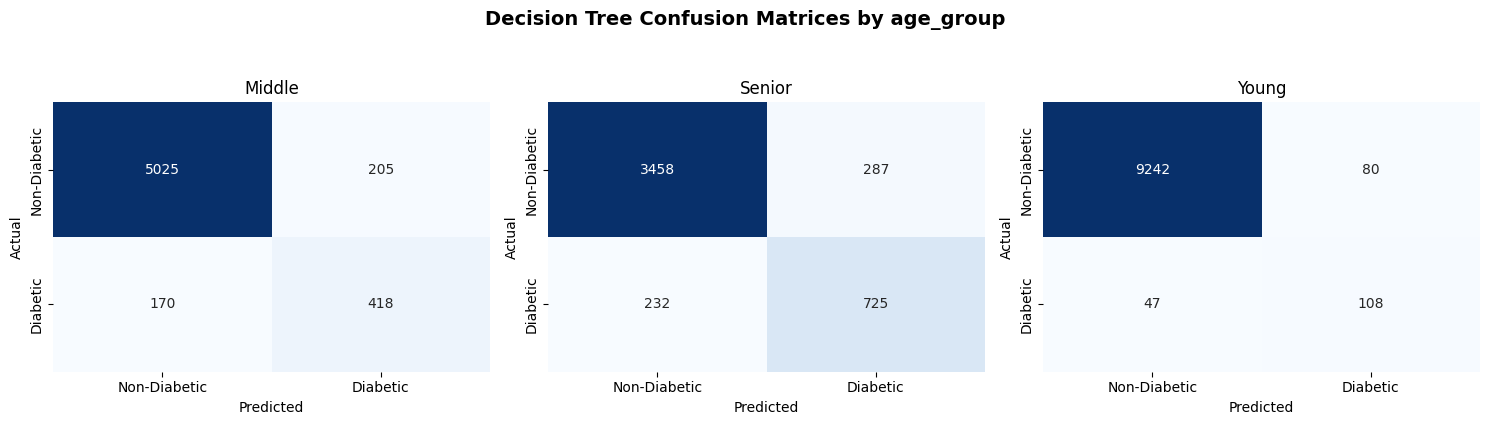

In [107]:
# Decision Tree: Confusion Matrices by Gender and Age Group
y_pred_dt = dt.predict(X_test_scaled)
plot_subgroup_matrices(y_test.reset_index(drop=True), y_pred_dt, sens_test.reset_index(drop=True), 'gender', 'Decision Tree')
plot_subgroup_matrices(y_test.reset_index(drop=True), y_pred_dt, sens_test.reset_index(drop=True), 'age_group', 'Decision Tree')

In [108]:
# Verifying sensitive attributes are saved correctly
print("Sensitive columns:", sensitive.columns.tolist())
print("\nSensitive shape:", sensitive.shape)
print("\nGender unique values:", sensitive['gender'].unique())
print("\nAge group unique values:", sensitive['age_group'].unique())
print("\nAny NaN in sensitive:")
print(sensitive.isna().sum())
print("\nSample:")
display(sensitive.head(10))

Sensitive columns: ['gender', 'age_group']

Sensitive shape: (99982, 2)

Gender unique values: ['Female' 'Male']

Age group unique values: ['Senior', 'Middle', 'Young']
Categories (3, object): ['Young' < 'Middle' < 'Senior']

Any NaN in sensitive:
gender       0
age_group    0
dtype: int64

Sample:


,gender,age_group
0,Female,Senior
1,Female,Middle
2,Male,Young
3,Female,Young
4,Male,Senior
5,Female,Young
6,Female,Middle
7,Female,Senior
8,Male,Middle
9,Female,Young


---

## 2. Ethical Concerns

Healthcare AI models carry significant ethical responsibility. Two core concerns arise:

**Class Imbalance:**
Only 8.5% of records are diabetic. A model that simply predicts "non-diabetic" for everyone
achieves 91.5% accuracy while missing all actual cases. This imbalance disproportionately
harms minority groups with lower representation in the diabetic class.

**Demographic Disparities Detected:**

The baseline models showed the following fairness issues across Gender and Age Group:

- **FNR disparity (Age):** Young patients had FNR up to 0.54 under LR — the model missed
  over half of all diabetic young patients. Senior patients had FNR as low as 0.31.
  This means young diabetic patients are systematically underdiagnosed.

- **Disparate Impact (Age):** Senior patients are predicted diabetic at 16.35% (LR) vs
  Young at 0.79% — a difference of 15.56%. Even accounting for clinical differences,
  this gap reflects the model amplifying age-based patterns.

- **Disparate Impact (Gender):** Male patients are predicted diabetic at a higher rate
  than Female across all three models (e.g. LR: 7.34% vs 5.31%).

- **Disparate Mistreatment (Age):** Error rates for Senior patients (8.63% under LR)
  are nearly 10x higher than for Young patients (0.93%) — confirmed as detected
  (disparity > 0.05).

In healthcare, a False Negative (missing a diabetic patient) is far more costly than a
False Positive. A model with unequal FNR across age groups is not just statistically
unfair — it is clinically dangerous for underdiagnosed groups.

# Fairness Analysis 1
## FPR, FNR, FDR, FOR per Sensitive Group

In [109]:
predictions = {
    "Logistic Regression": lr.predict(X_test_scaled),
    "Random Forest": rf.predict(X_test_scaled),
    "Decision Tree": dt.predict(X_test_scaled)
}
def compute_a1_metrics(y_true, y_pred, sens, attr, model_name):
    print(f"\n{'='*60}")
    print(f"  {model_name} — {attr}")
    print(f"{'='*60}")

    groups = sorted(sens[attr].dropna().unique(), key=str)
    results = []

    for group in groups:
        mask  = sens[attr] == group
        yt    = y_true[mask]
        yp    = y_pred[mask]
        cm    = confusion_matrix(yt, yp, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()

        fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr  = fn / (fn + tp) if (fn + tp) > 0 else 0
        fdr  = fp / (fp + tp) if (fp + tp) > 0 else 0
        for_ = fn / (fn + tn) if (fn + tn) > 0 else 0

        print(f"\n  Group : {group}")
        print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
        print(f"  FPR = {fp}/({fp}+{tn}) = {fpr:.4f}")
        print(f"  FNR = {fn}/({fn}+{tp}) = {fnr:.4f}")
        print(f"  FDR = {fp}/({fp}+{tp}) = {fdr:.4f}")
        print(f"  FOR = {fn}/({fn}+{tn}) = {for_:.4f}")

        results.append({
            'Group': group, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'FPR': round(fpr,4), 'FNR': round(fnr,4),
            'FDR': round(fdr,4), 'FOR': round(for_,4)
        })

    df_res = pd.DataFrame(results)
    print(f"\n  Disparities:")
    print(f"  FPR = {df_res['FPR'].max() - df_res['FPR'].min():.4f}")
    print(f"  FNR = {df_res['FNR'].max() - df_res['FNR'].min():.4f}")
    print(f"  FDR = {df_res['FDR'].max() - df_res['FDR'].min():.4f}")
    print(f"  FOR = {df_res['FOR'].max() - df_res['FOR'].min():.4f}")
    display(df_res)
    return df_res

sens_test_reset = sens_test.reset_index(drop=True)
y_test_reset    = y_test.reset_index(drop=True)

# Dictionaries to store the results from compute_a1_metrics
all_gender_metrics = {}
all_age_metrics = {}

for model_name, y_pred in predictions.items():
    for attr in ['gender', 'age_group']:
        df_res = compute_a1_metrics(y_test_reset, y_pred, sens_test_reset, attr, model_name)
        if attr == 'gender':
            all_gender_metrics[model_name] = df_res
        elif attr == 'age_group':
            all_age_metrics[model_name] = df_res

# Assigning to individual variables for compatibility with existing plot_clean_metrics calls
lr_gender = all_gender_metrics['Logistic Regression']
lr_age = all_age_metrics['Logistic Regression']
rf_gender = all_gender_metrics['Random Forest']
rf_age = all_age_metrics['Random Forest']
dt_gender = all_gender_metrics['Decision Tree']
dt_age = all_age_metrics['Decision Tree']


  Logistic Regression — gender

  Group : Female
  TP=554  TN=10701  FP=65  FN=342
  FPR = 65/(65+10701) = 0.0060
  FNR = 342/(342+554) = 0.3817
  FDR = 65/(65+554) = 0.1050
  FOR = 342/(342+10701) = 0.0310

  Group : Male
  TP=527  TN=7446  FP=85  FN=277
  FPR = 85/(85+7446) = 0.0113
  FNR = 277/(277+527) = 0.3445
  FDR = 85/(85+527) = 0.1389
  FOR = 277/(277+7446) = 0.0359

  Disparities:
  FPR = 0.0053
  FNR = 0.0372
  FDR = 0.0339
  FOR = 0.0049


,Group,TP,TN,FP,FN,FPR,FNR,FDR,FOR
0,Female,554,10701,65,342,0.0060,0.3817,0.1050,0.0310
1,Male,527,7446,85,277,0.0113,0.3445,0.1389,0.0359



  Logistic Regression — age_group

  Group : Middle
  TP=350  TN=5193  FP=37  FN=238
  FPR = 37/(37+5193) = 0.0071
  FNR = 238/(238+350) = 0.4048
  FDR = 37/(37+350) = 0.0956
  FOR = 238/(238+5193) = 0.0438

  Group : Senior
  TP=660  TN=3636  FP=109  FN=297
  FPR = 109/(109+3636) = 0.0291
  FNR = 297/(297+660) = 0.3103
  FDR = 109/(109+660) = 0.1417
  FOR = 297/(297+3636) = 0.0755

  Group : Young
  TP=71  TN=9318  FP=4  FN=84
  FPR = 4/(4+9318) = 0.0004
  FNR = 84/(84+71) = 0.5419
  FDR = 4/(4+71) = 0.0533
  FOR = 84/(84+9318) = 0.0089

  Disparities:
  FPR = 0.0287
  FNR = 0.2316
  FDR = 0.0884
  FOR = 0.0666


,Group,TP,TN,FP,FN,FPR,FNR,FDR,FOR
0,Middle,350,5193,37,238,0.0071,0.4048,0.0956,0.0438
1,Senior,660,3636,109,297,0.0291,0.3103,0.1417,0.0755
2,Young,71,9318,4,84,0.0004,0.5419,0.0533,0.0089



  Random Forest — gender

  Group : Female
  TP=614  TN=10723  FP=43  FN=282
  FPR = 43/(43+10723) = 0.0040
  FNR = 282/(282+614) = 0.3147
  FDR = 43/(43+614) = 0.0654
  FOR = 282/(282+10723) = 0.0256

  Group : Male
  TP=559  TN=7505  FP=26  FN=245
  FPR = 26/(26+7505) = 0.0035
  FNR = 245/(245+559) = 0.3047
  FDR = 26/(26+559) = 0.0444
  FOR = 245/(245+7505) = 0.0316

  Disparities:
  FPR = 0.0005
  FNR = 0.0100
  FDR = 0.0210
  FOR = 0.0060


...

,Group,TP,TN,FP,FN,FPR,FNR,FDR,FOR
0,Middle,397,5211,19,191,0.0036,0.3248,0.0457,0.0354
1,Senior,671,3697,48,286,0.0128,0.2989,0.0668,0.0718
2,Young,105,9320,2,50,0.0002,0.3226,0.0187,0.0053



  Decision Tree — gender

  Group : Female
  TP=651  TN=10455  FP=311  FN=245
  FPR = 311/(311+10455) = 0.0289
  FNR = 245/(245+651) = 0.2734
  FDR = 311/(311+651) = 0.3233
  FOR = 245/(245+10455) = 0.0229

  Group : Male
  TP=600  TN=7270  FP=261  FN=204
  FPR = 261/(261+7270) = 0.0347
  FNR = 204/(204+600) = 0.2537
  FDR = 261/(261+600) = 0.3031
  FOR = 204/(204+7270) = 0.0273

  Disparities:
  FPR = 0.0058
  FNR = 0.0197
  FDR = 0.0202
  FOR = 0.0044


,Group,TP,TN,FP,FN,FPR,FNR,FDR,FOR
0,Female,651,10455,311,245,0.0289,0.2734,0.3233,0.0229
1,Male,600,7270,261,204,0.0347,0.2537,0.3031,0.0273



  Decision Tree — age_group

  Group : Middle
  TP=418  TN=5025  FP=205  FN=170
  FPR = 205/(205+5025) = 0.0392
  FNR = 170/(170+418) = 0.2891
  FDR = 205/(205+418) = 0.3291
  FOR = 170/(170+5025) = 0.0327

  Group : Senior
  TP=725  TN=3458  FP=287  FN=232
  FPR = 287/(287+3458) = 0.0766
  FNR = 232/(232+725) = 0.2424
  FDR = 287/(287+725) = 0.2836
  FOR = 232/(232+3458) = 0.0629

  Group : Young
  TP=108  TN=9242  FP=80  FN=47
  FPR = 80/(80+9242) = 0.0086
  FNR = 47/(47+108) = 0.3032
  FDR = 80/(80+108) = 0.4255
  FOR = 47/(47+9242) = 0.0051

  Disparities:
  FPR = 0.0680
  FNR = 0.0608
  FDR = 0.1419
  FOR = 0.0578


,Group,TP,TN,FP,FN,FPR,FNR,FDR,FOR
0,Middle,418,5025,205,170,0.0392,0.2891,0.3291,0.0327
1,Senior,725,3458,287,232,0.0766,0.2424,0.2836,0.0629
2,Young,108,9242,80,47,0.0086,0.3032,0.4255,0.0051


## Visual Comparison

In [110]:
def plot_clean_metrics(data_gender, data_age, model_name, colors):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for i, metric in enumerate(['FPR', 'FNR', 'FDR', 'FOR']):
        combined = pd.concat([data_gender, data_age])
        combined.set_index('Group')[metric].plot(kind='bar', ax=axes[i], color=colors, rot=0)
        axes[i].set(title=metric, xlabel='', ylabel='', yticks=[])
        axes[i].spines[['top', 'right', 'left']].set_visible(False)
        axes[i].bar_label(axes[i].containers[0], fmt=' %.3f', fontsize=9, fontweight='bold')
    plt.suptitle(f'{model_name} Fairness Metrics', fontsize=16, fontweight='bold', y=1.1); plt.tight_layout(); plt.show()

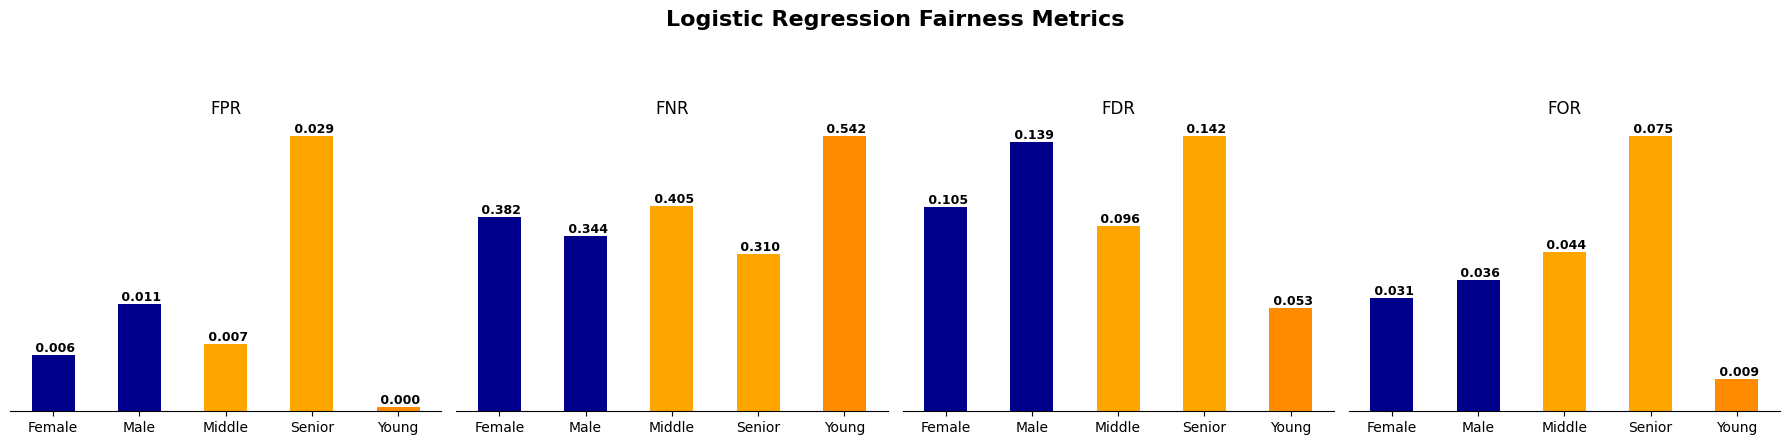

In [111]:
plot_clean_metrics(lr_gender, lr_age, 'Logistic Regression', ['darkblue', 'darkblue', 'orange', 'orange', 'darkorange'])

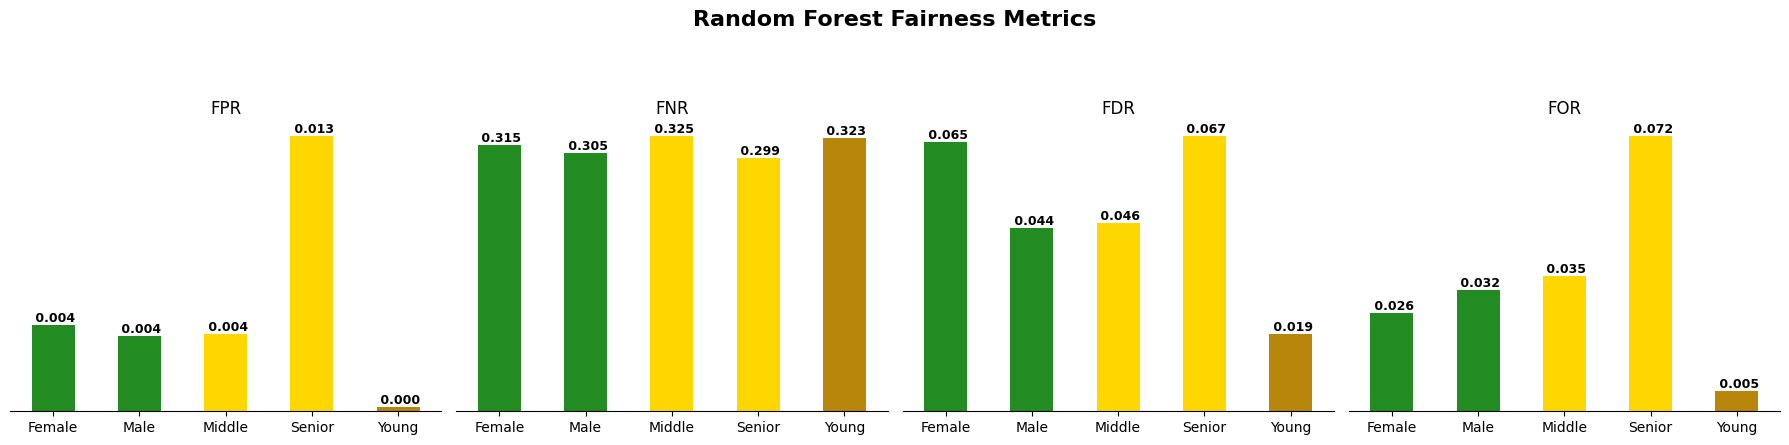

In [112]:
plot_clean_metrics(rf_gender, rf_age, 'Random Forest', ['forestgreen', 'forestgreen', 'gold', 'gold', 'darkgoldenrod'])

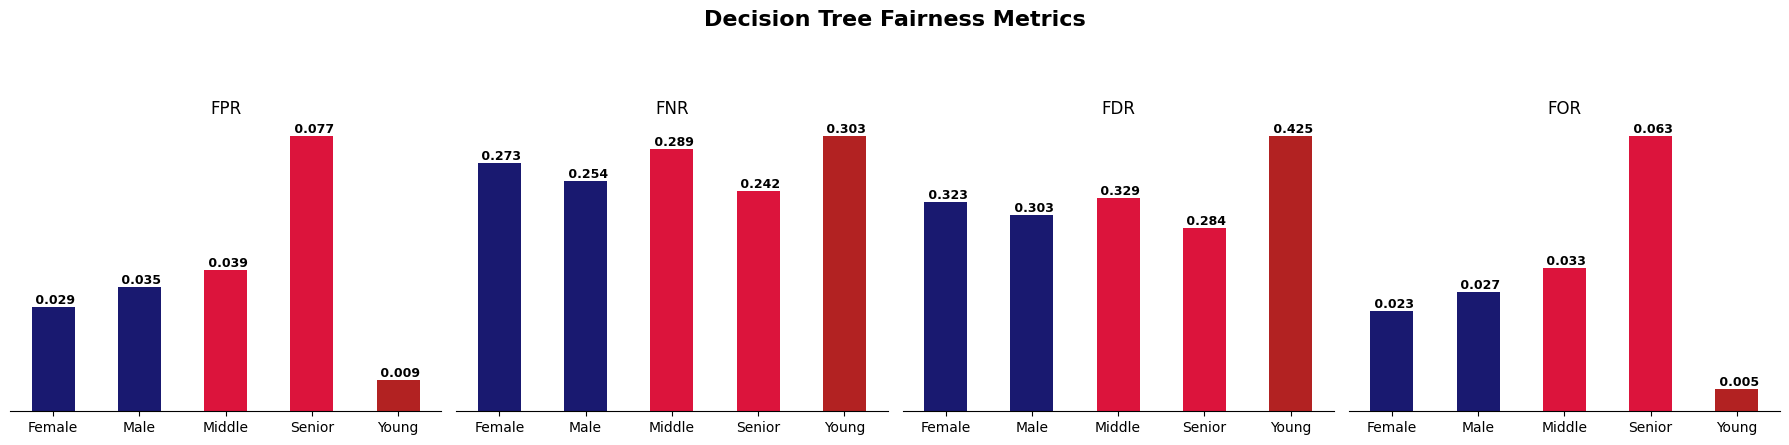

In [113]:
plot_clean_metrics(dt_gender, dt_age, 'Decision Tree', ['midnightblue', 'midnightblue', 'crimson', 'crimson', 'firebrick'])

# Fairness Analysis 2
## Disparate Impact
### Formula: P(ŷ=1 | z=0) = P(ŷ=1 | z=1)
### Rate = predicted positive count / total in group
### Difference = max rate − min rate across groups

In [114]:
def compute_disparate_impact(y_pred, sens, attr, model_name):
    print(f"\n{'='*60}")
    print(f"  {model_name} — Disparate Impact — {attr}")
    print(f"{'='*60}")

    groups = sorted(sens[attr].dropna().unique(), key=str)
    rates  = {}

    for group in groups:
        mask     = sens[attr] == group
        total    = mask.sum()
        positive = y_pred[mask].sum()
        rate     = positive / total
        rates[group] = rate
        print(f"  P(ŷ=1 | {str(group):10s}) = {int(positive):4d} / {int(total):5d} = {rate:.4f}")

    diff    = max(rates.values()) - min(rates.values())
    max_grp = max(rates, key=rates.get)
    min_grp = min(rates, key=rates.get)
    verdict = "DETECTED" if diff > 0 else "FAIR"

    print(f"\n  Highest : {max_grp} = {rates[max_grp]:.4f}")
    print(f"  Lowest  : {min_grp} = {rates[min_grp]:.4f}")
    print(f"  Difference = {rates[max_grp]:.4f} - {rates[min_grp]:.4f} = {diff:.4f} → {verdict}")

for model_name, y_pred in [("Logistic Regression", y_pred_lr),
                             ("Random Forest",       y_pred_rf),
                             ("Decision Tree",       y_pred_dt)]:
    for attr in ['gender', 'age_group']:
        compute_disparate_impact(
            pd.Series(y_pred), sens_test_reset, attr, model_name)


  Logistic Regression — Disparate Impact — gender
  P(ŷ=1 | Female    ) =  619 / 11662 = 0.0531
  P(ŷ=1 | Male      ) =  612 /  8335 = 0.0734

  Highest : Male = 0.0734
  Lowest  : Female = 0.0531
  Difference = 0.0734 - 0.0531 = 0.0203 → DETECTED

  Logistic Regression — Disparate Impact — age_group
  P(ŷ=1 | Middle    ) =  387 /  5818 = 0.0665
  P(ŷ=1 | Senior    ) =  769 /  4702 = 0.1635
  P(ŷ=1 | Young     ) =   75 /  9477 = 0.0079

  Highest : Senior = 0.1635
  Lowest  : Young = 0.0079
  Difference = 0.1635 - 0.0079 = 0.1556 → DETECTED

  Random Forest — Disparate Impact — gender
  P(ŷ=1 | Female    ) =  657 / 11662 = 0.0563
  P(ŷ=1 | Male      ) =  585 /  8335 = 0.0702

  Highest : Male = 0.0702
  Lowest  : Female = 0.0563
  Difference = 0.0702 - 0.0563 = 0.0138 → DETECTED

  Random Forest — Disparate Impact — age_group
  P(ŷ=1 | Middle    ) =  416 /  5818 = 0.0715
  P(ŷ=1 | Senior    ) =  719 /  4702 = 0.1529
  P(ŷ=1 | Young     ) =  107 /  9477 = 0.0113

  Highest : Senior = 0

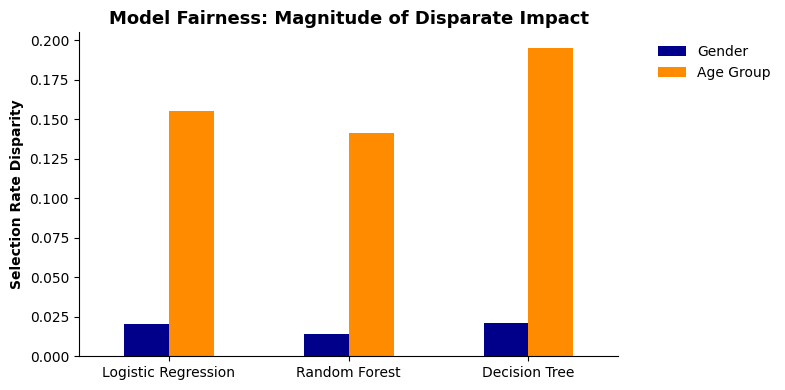

In [115]:
summary = {
    'Logistic Regression': {'Gender': 0.0203, 'Age Group': 0.1556},
    'Random Forest':       {'Gender': 0.0138, 'Age Group': 0.1416},
    'Decision Tree':       {'Gender': 0.0208, 'Age Group': 0.1954}
}
df_summary = pd.DataFrame(summary).T

ax = df_summary.plot(kind='bar', figsize=(8, 4), color=['darkblue', 'darkorange'], rot=0)
plt.title('Model Fairness: Magnitude of Disparate Impact', fontweight='bold', fontsize=13)
plt.ylabel('Selection Rate Disparity', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1))
plt.tight_layout(); plt.show()

## Disparate Mistreatment
### Formula: P(ŷ ≠ y | z=0) = P(ŷ ≠ y | z=1)
### Error rate = wrong predictions / total per group
### Disparity = max rate − min rate. If disparity > 0.05 → Detected

In [116]:
def compute_disparate_mistreatment(y_true, y_pred, sens, attr, model_name):
    print(f"\n{'='*60}")
    print(f"  {model_name} — Disparate Mistreatment — {attr}")
    print(f"{'='*60}")

    groups = sorted(sens[attr].dropna().unique(), key=str)
    errors = {}

    for group in groups:
        mask       = sens[attr] == group
        total      = mask.sum()
        wrong      = (y_pred[mask] != y_true[mask]).sum()
        error_rate = wrong / total
        errors[group] = error_rate
        print(f"  Error({str(group):10s}) = {int(wrong):4d} / {int(total):5d} = {error_rate:.4f}")

    diff    = max(errors.values()) - min(errors.values())
    max_grp = max(errors, key=errors.get)
    min_grp = min(errors, key=errors.get)
    verdict = "DETECTED" if diff > 0.05 else "FAIR"

    print(f"\n  Highest : {max_grp} = {errors[max_grp]:.4f}")
    print(f"  Lowest  : {min_grp} = {errors[min_grp]:.4f}")
    print(f"  Disparity = {errors[max_grp]:.4f} - {errors[min_grp]:.4f} = {diff:.4f} → {verdict}")

for model_name, y_pred in [("Logistic Regression", y_pred_lr),
                             ("Random Forest",       y_pred_rf),
                             ("Decision Tree",       y_pred_dt)]:
    for attr in ['gender', 'age_group']:
        compute_disparate_mistreatment(
            y_test_reset, pd.Series(y_pred),
            sens_test_reset, attr, model_name)


  Logistic Regression — Disparate Mistreatment — gender
  Error(Female    ) =  407 / 11662 = 0.0349
  Error(Male      ) =  362 /  8335 = 0.0434

  Highest : Male = 0.0434
  Lowest  : Female = 0.0349
  Disparity = 0.0434 - 0.0349 = 0.0085 → FAIR

  Logistic Regression — Disparate Mistreatment — age_group
  Error(Middle    ) =  275 /  5818 = 0.0473
  Error(Senior    ) =  406 /  4702 = 0.0863
  Error(Young     ) =   88 /  9477 = 0.0093

  Highest : Senior = 0.0863
  Lowest  : Young = 0.0093
  Disparity = 0.0863 - 0.0093 = 0.0771 → DETECTED

  Random Forest — Disparate Mistreatment — gender
  Error(Female    ) =  325 / 11662 = 0.0279
  Error(Male      ) =  271 /  8335 = 0.0325

  Highest : Male = 0.0325
  Lowest  : Female = 0.0279
  Disparity = 0.0325 - 0.0279 = 0.0046 → FAIR

  Random Forest — Disparate Mistreatment — age_group
  Error(Middle    ) =  210 /  5818 = 0.0361
  Error(Senior    ) =  334 /  4702 = 0.0710
  Error(Young     ) =   52 /  9477 = 0.0055

  Highest : Senior = 0.0710
 

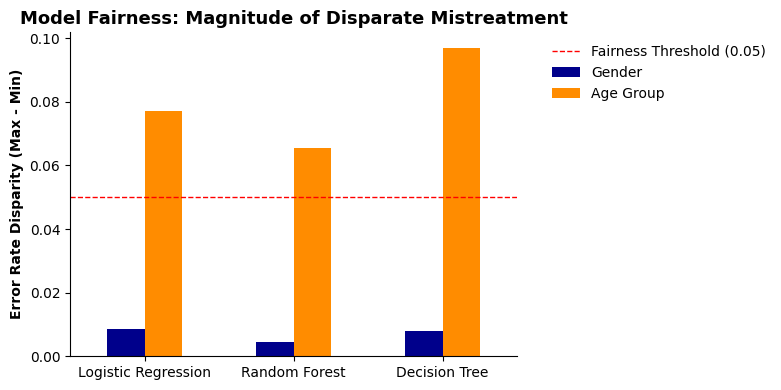

In [117]:
mistreatment_summary = {
    'Logistic Regression': {'Gender': 0.0085, 'Age Group': 0.0771},
    'Random Forest':       {'Gender': 0.0046, 'Age Group': 0.0655},
    'Decision Tree':       {'Gender': 0.0081, 'Age Group': 0.0970}
}

df_mistreat = pd.DataFrame(mistreatment_summary).T

ax = df_mistreat.plot(kind='bar', figsize=(8, 4), color=['darkblue', 'darkorange'], rot=0)
plt.title('Model Fairness: Magnitude of Disparate Mistreatment', fontweight='bold', fontsize=13)
plt.ylabel('Error Rate Disparity (Max - Min)', fontweight='bold')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='Fairness Threshold (0.05)')
ax.spines[['top', 'right']].set_visible(False)
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1))
plt.tight_layout(); plt.show()

## Disparate Treatment
### Formula: P(ŷ|x,z) = P(ŷ|x)
### For each pair sharing identical non-sensitive attributes but different sensitive attribute
### Rate = pairs with different predictions / total pairs

In [118]:
non_sensitive_cols = ['age', 'hypertension', 'heart_disease',
                      'smoking_encoded', 'bmi', 'HbA1c_level',
                      'blood_glucose_level']

def compute_disparate_treatment(model, X_test_scaled, X_test_df,
                                sens, model_name):
    print(f"\n{'='*60}")
    print(f"  {model_name} — Disparate Treatment")
    print(f"{'='*60}")

    preds = model.predict(X_test_scaled)

    test_df = X_test_df.copy().reset_index(drop=True)
    test_df['gender']     = sens['gender'].values
    test_df['age_group']  = sens['age_group'].values
    test_df['prediction'] = preds

    print("\n  --- GENDER (Male vs Female) ---")
    groups    = test_df.groupby(non_sensitive_cols)
    total     = 0
    diff      = 0

    for _, group in groups:
        males   = group[group['gender'] == 'Female']
        females = group[group['gender'] == 'Male']
        if len(males) > 0 and len(females) > 0:
            for _, m in males.iterrows():
                for _, f in females.iterrows():
                    total += 1
                    if m['prediction'] != f['prediction']:
                        diff += 1

    pct     = (diff / total * 100) if total > 0 else 0
    verdict = "DETECTED" if diff > 0 else "NO Disparate Treatment"
    print(f"  Total pairs  : {total}")
    print(f"  Diff preds   : {diff}")
    print(f"  Rate = {diff}/{total} = {pct:.2f}%  →  {verdict}")

    print("\n  --- AGE GROUP (all pairs) ---")
    age_groups = sorted(test_df['age_group'].dropna().unique(), key=str)
    age_pairs  = list(combinations(age_groups, 2))

    for a1, a2 in age_pairs:
        total_a = 0
        diff_a  = 0
        for _, group in groups:
            g1 = group[group['age_group'] == a1]
            g2 = group[group['age_group'] == a2]
            if len(g1) > 0 and len(g2) > 0:
                for _, r1 in g1.iterrows():
                    for _, r2 in g2.iterrows():
                        total_a += 1
                        if r1['prediction'] != r2['prediction']:
                            diff_a += 1
        pct_a     = (diff_a / total_a * 100) if total_a > 0 else 0
        verdict_a = "DETECTED" if diff_a > 0 else "NO Disparate Treatment"
        print(f"  {str(a1):8s} vs {str(a2):8s} | Pairs={total_a:4d} | Diff={diff_a:4d} | {pct_a:.2f}% → {verdict_a}")

X_test_df_reset = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
).reset_index(drop=True)

for model_name, model in [("Logistic Regression", lr),
                            ("Random Forest",       rf),
                            ("Decision Tree",       dt)]:
    compute_disparate_treatment(
        model, X_test_scaled,
        X_test_df_reset, sens_test_reset, model_name)


  Logistic Regression — Disparate Treatment

  --- GENDER (Male vs Female) ---
  Total pairs  : 223
  Diff preds   : 0
  Rate = 0/223 = 0.00%  →  NO Disparate Treatment

  --- AGE GROUP (all pairs) ---
  Middle   vs Senior   | Pairs=   0 | Diff=   0 | 0.00% → NO Disparate Treatment
  Middle   vs Young    | Pairs=   0 | Diff=   0 | 0.00% → NO Disparate Treatment
  Senior   vs Young    | Pairs=   0 | Diff=   0 | 0.00% → NO Disparate Treatment

  Random Forest — Disparate Treatment

  --- GENDER (Male vs Female) ---
  Total pairs  : 223
  Diff preds   : 3
  Rate = 3/223 = 1.35%  →  DETECTED

  --- AGE GROUP (all pairs) ---
  Middle   vs Senior   | Pairs=   0 | Diff=   0 | 0.00% → NO Disparate Treatment
  Middle   vs Young    | Pairs=   0 | Diff=   0 | 0.00% → NO Disparate Treatment
  Senior   vs Young    | Pairs=   0 | Diff=   0 | 0.00% → NO Disparate Treatment

  Decision Tree — Disparate Treatment

  --- GENDER (Male vs Female) ---
  Total pairs  : 223
  Diff preds   : 6
  Rate = 6/223

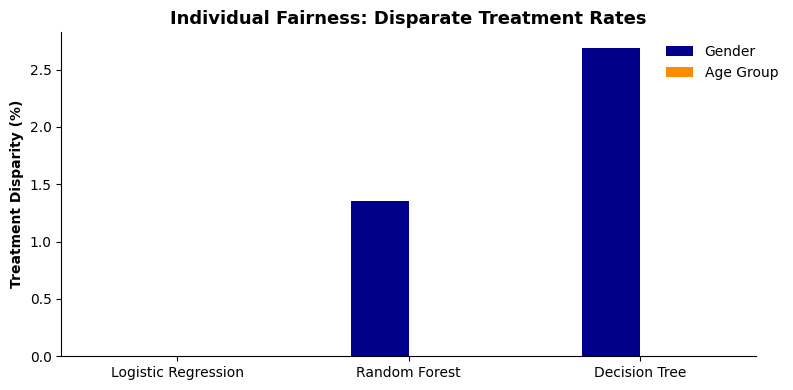

In [119]:
dt_summary = {
    'Logistic Regression': {'Gender': 0.00, 'Age Group': 0.00},
    'Random Forest':       {'Gender': 1.35, 'Age Group': 0.00},
    'Decision Tree':       {'Gender': 2.69, 'Age Group': 0.00}
}
df_dt = pd.DataFrame(dt_summary).T

ax = df_dt.plot(kind='bar', figsize=(8, 4), color=['darkblue', 'darkorange'], rot=0)
plt.title('Individual Fairness: Disparate Treatment Rates', fontweight='bold', fontsize=13)
plt.ylabel('Treatment Disparity (%)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1))
plt.tight_layout(); plt.show()

# Fairness Analysis 3
## Discrimination Discovery: Support, Confidence, Extended Lift
### PD Rule: A, B → C where A = protected group, B = context, C = outcome
### Support(A,B→C) = σ(A ∩ B ∩ C) / N
### Confidence(A,B→C) = σ(A ∩ B ∩ C) / σ(A ∩ B)
### eliftB(A,B→C) = conf(A,B→C) / conf(B→C)
### If eliftB ≥ 1.5 → discriminatory | If eliftB < 1.5 → α-protective

In [120]:
def compute_discrimination_discovery(y_true, y_pred, sens,
                                     protected_attr, protected_val,
                                     context_attr, context_val,
                                     outcome, model_name):
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"  PD Rule: {protected_attr}={protected_val}, "
          f"{context_attr}={context_val} → {outcome}")
    print(f"{'='*60}")

    N = len(y_true)

    # A = protected group
    mask_A = sens[protected_attr] == protected_val

    # B = context
    if context_attr == 'age_group':
        mask_B = sens[context_attr] == context_val
    else:
        mask_B = y_true == context_val

    # C = outcome (Diabetic = 1)
    mask_C = pd.Series(y_pred) == outcome

    mask_AB  = mask_A & mask_B
    mask_ABC = mask_A & mask_B & mask_C
    mask_BC  = mask_B & mask_C

    sigma_AB  = mask_AB.sum()
    sigma_ABC = mask_ABC.sum()
    sigma_B   = mask_B.sum()
    sigma_BC  = mask_BC.sum()

    support    = sigma_ABC / N
    confidence = sigma_ABC / sigma_AB  if sigma_AB  > 0 else 0
    conf_B     = sigma_BC  / sigma_B   if sigma_B   > 0 else 0
    elift      = confidence / conf_B   if conf_B    > 0 else 0
    verdict    = "DISCRIMINATORY" if elift >= 1.5 else "alpha-PROTECTIVE"

    print(f"\n  σ(A∩B)   = {sigma_AB}")
    print(f"  σ(A∩B∩C) = {sigma_ABC}")
    print(f"  σ(B)     = {sigma_B}")
    print(f"  σ(B∩C)   = {sigma_BC}")
    print(f"\n  Support    = {sigma_ABC}/{N} = {support:.4f}")
    print(f"  Confidence = {sigma_ABC}/{sigma_AB} = {confidence:.4f}")
    print(f"  conf(B→C)  = {sigma_BC}/{sigma_B} = {conf_B:.4f}")
    print(f"  eliftB     = {confidence:.4f} / {conf_B:.4f} = {elift:.4f}")
    print(f"  Verdict    : eliftB={elift:.4f} {'≥' if elift>=1.5 else '<'} 1.5 → {verdict}")

y_pred_series = {
    "Logistic Regression": pd.Series(y_pred_lr),
    "Random Forest":       pd.Series(y_pred_rf),
    "Decision Tree":       pd.Series(y_pred_dt)
}

y_true_reset = y_test_reset.reset_index(drop=True)

print("\n" + "="*60)
print("  RULE 1: Female, Senior → Diabetic")
print("="*60)
for model_name, y_pred in y_pred_series.items():
    compute_discrimination_discovery(
        y_true_reset, y_pred, sens_test_reset,
        protected_attr='gender',   protected_val='Female',
        context_attr='age_group',  context_val='Senior',
        outcome=1, model_name=model_name
    )

print("\n" + "="*60)
print("  RULE 2: Male, Senior → Diabetic")
print("="*60)
for model_name, y_pred in y_pred_series.items():
    compute_discrimination_discovery(
        y_true_reset, y_pred, sens_test_reset,
        protected_attr='gender',   protected_val='Male',
        context_attr='age_group',  context_val='Senior',
        outcome=1, model_name=model_name
    )

print("\n" + "="*60)
print("  RULE 3: Female, Young → Diabetic")
print("="*60)
for model_name, y_pred in y_pred_series.items():
    compute_discrimination_discovery(
        y_true_reset, y_pred, sens_test_reset,
        protected_attr='gender',   protected_val='Female',
        context_attr='age_group',  context_val='Young',
        outcome=1, model_name=model_name
    )


  RULE 1: Female, Senior → Diabetic

  Logistic Regression
  PD Rule: gender=Female, age_group=Senior → 1

  σ(A∩B)   = 2753
  σ(A∩B∩C) = 392
  σ(B)     = 4702
  σ(B∩C)   = 769

  Support    = 392/19997 = 0.0196
  Confidence = 392/2753 = 0.1424
  conf(B→C)  = 769/4702 = 0.1635
  eliftB     = 0.1424 / 0.1635 = 0.8706
  Verdict    : eliftB=0.8706 < 1.5 → alpha-PROTECTIVE

  Random Forest
  PD Rule: gender=Female, age_group=Senior → 1

  σ(A∩B)   = 2753
  σ(A∩B∩C) = 383
  σ(B)     = 4702
  σ(B∩C)   = 719

  Support    = 383/19997 = 0.0192
  Confidence = 383/2753 = 0.1391
  conf(B→C)  = 719/4702 = 0.1529
  eliftB     = 0.1391 / 0.1529 = 0.9098
  Verdict    : eliftB=0.9098 < 1.5 → alpha-PROTECTIVE

  Decision Tree
  PD Rule: gender=Female, age_group=Senior → 1

  σ(A∩B)   = 2753
  σ(A∩B∩C) = 533
  σ(B)     = 4702
  σ(B∩C)   = 1012

  Support    = 533/19997 = 0.0267
  Confidence = 533/2753 = 0.1936
  conf(B→C)  = 1012/4702 = 0.2152
  eliftB     = 0.1936 / 0.2152 = 0.8995
  Verdict    : elif

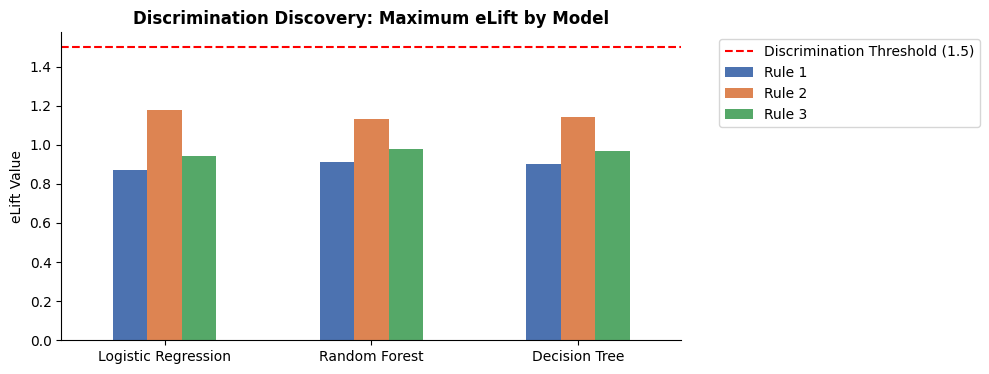

In [121]:
elift_summary = {
    'Logistic Regression': {'Rule 1': 0.87, 'Rule 2': 1.18, 'Rule 3': 0.94},
    'Random Forest':       {'Rule 1': 0.91, 'Rule 2': 1.13, 'Rule 3': 0.98},
    'Decision Tree':       {'Rule 1': 0.90, 'Rule 2': 1.14, 'Rule 3': 0.97}
}
df_elift = pd.DataFrame(elift_summary).T

ax = df_elift.plot(kind='bar', figsize=(8, 4), color=['#4C72B0', '#DD8452', '#55A868'], rot=0)
plt.axhline(1.5, color='red', linestyle='--', linewidth=1.5, label='Discrimination Threshold (1.5)')
plt.title('Discrimination Discovery: Maximum eLift by Model', fontweight='bold')
plt.ylabel('eLift Value')
plt.legend(bbox_to_anchor=(1.05, 1))
sns.despine(); plt.show()

## Bias Mitigation Approaches

Several approaches exist to address algorithmic bias:

**1. Reweighting (chosen approach)**
Assign higher sample weights to underrepresented group-label combinations during training.
This directly addresses data-level imbalance without changing the model architecture.
Simple, interpretable, and compatible with standard sklearn classifiers.

**2. Resampling (SMOTE)**
Oversample minority demographic groups to balance representation.
Risk: can introduce synthetic noise; does not address feature-level bias.

**3. Fairlearn constraints**
Apply explicit fairness constraints during training (e.g. equalised odds).
More powerful but harder to interpret and justify to non-technical stakeholders.

**4. Adversarial Debiasing**
Use an adversarial network to remove sensitive information from predictions.
Most complex requires significant architectural changes.

Reweighting is the most interpretable approach the fairness improvement can be directly
attributed to the weight adjustments rather than architectural changes. It preserves the
original model structure, making it easier to audit and explain to regulators. It is also
the most appropriate given the data-level source of bias (class imbalance combined with
demographic imbalance).

# Bias Mitigation — Reweighting
## Approach: Assign higher sample weights to underrepresented groups
## Goal: Reduce disparity in error rates across Gender and Age groups

In [122]:
def compute_sample_weights(y_train, sens_train):
    sens_train_reset = sens_train.reset_index(drop=True)
    y_train_reset    = y_train.reset_index(drop=True)

    n = len(y_train_reset)
    weights = np.ones(n)

    groups = sens_train_reset.copy()
    groups['label'] = y_train_reset.values

    group_counts = groups.groupby(
        ['gender', 'age_group', 'label']
    ).size().reset_index(name='count')
    group_counts['weight'] = n / (
        group_counts.groupby('label')['count'].transform('sum') *
        group_counts['count']
    )

    for _, row in group_counts.iterrows():
        mask = (
            (sens_train_reset['gender']    == row['gender']) &
            (sens_train_reset['age_group'] == row['age_group']) &
            (y_train_reset                 == row['label'])
        )
        weights[mask] = row['weight']

    return weights

sample_weights = compute_sample_weights(y_train, sens_train)

print("Sample weights computed.")
print(f"Min weight : {sample_weights.min():.4f}")
print(f"Max weight : {sample_weights.max():.4f}")
print(f"Mean weight: {sample_weights.mean():.4f}")

Sample weights computed.
Min weight : 0.0001
Max weight : 0.0432
Mean weight: 0.0010


## Retrain Models with Sample Weights

In [123]:
# Logistic Regression with weights
lr_w = LogisticRegression(max_iter=1000, random_state=42)
lr_w.fit(X_train_scaled, y_train, sample_weight=sample_weights)
y_pred_lr_w = lr_w.predict(X_test_scaled)

# Random Forest with weights
rf_w = RandomForestClassifier(n_estimators=100, random_state=42)
rf_w.fit(X_train_scaled, y_train, sample_weight=sample_weights)
y_pred_rf_w = rf_w.predict(X_test_scaled)

# Decision Tree with weights
dt_w = DecisionTreeClassifier(random_state=42)
dt_w.fit(X_train_scaled, y_train, sample_weight=sample_weights)
y_pred_dt_w = dt_w.predict(X_test_scaled)

print("Logistic Regression (weighted):")
print(classification_report(y_test, y_pred_lr_w))
print("\nRandom Forest (weighted):")
print(classification_report(y_test, y_pred_rf_w))
print("\nDecision Tree (weighted):")
print(classification_report(y_test, y_pred_dt_w))

Logistic Regression (weighted):
              precision    recall  f1-score   support

           0       1.00      0.40      0.58     18297
           1       0.13      1.00      0.24      1700

    accuracy                           0.45     19997
   macro avg       0.57      0.70      0.41     19997
weighted avg       0.93      0.45      0.55     19997


Random Forest (weighted):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18297
           1       0.94      0.69      0.79      1700

    accuracy                           0.97     19997
   macro avg       0.96      0.84      0.89     19997
weighted avg       0.97      0.97      0.97     19997


Decision Tree (weighted):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18297
           1       0.75      0.73      0.74      1700

    accuracy                           0.96     19997
   macro avg       0.86      0.85      0.8

# Before vs After Reweighting Comparison

In [124]:
print("="*65)
print("  BEFORE vs AFTER — Disparate Mistreatment")
print("="*65)

for model_name, y_before, y_after in [
    ("Logistic Regression", y_pred_lr,  y_pred_lr_w),
    ("Random Forest",       y_pred_rf,  y_pred_rf_w),
    ("Decision Tree",       y_pred_dt,  y_pred_dt_w)
]:
    print(f"\n--- {model_name} ---")
    for attr in ['gender', 'age_group']:
        groups = sorted(sens_test_reset[attr].dropna().unique(), key=str)
        errors_before = {}
        errors_after  = {}

        for group in groups:
            mask  = sens_test_reset[attr] == group
            total = mask.sum()
            errors_before[group] = (y_before[mask] != y_test_reset[mask]).sum() / total
            errors_after[group]  = (pd.Series(y_after)[mask] != y_test_reset[mask]).sum() / total

        disp_before = max(errors_before.values()) - min(errors_before.values())
        disp_after  = max(errors_after.values())  - min(errors_after.values())
        change      = disp_after - disp_before
        direction   = "IMPROVED" if change < 0 else "WORSE" if change > 0 else "NO CHANGE"

        print(f"\n  {attr.upper()}:")
        for group in groups:
            print(f"  {str(group):10s} Before={errors_before[group]:.4f}  After={errors_after[group]:.4f}")
        print(f"  Disparity Before = {disp_before:.4f}")
        print(f"  Disparity After  = {disp_after:.4f}")
        print(f"  Change           = {change:+.4f}  →  {direction}")

print("\n" + "="*65)
print("  BEFORE vs AFTER — Disparate Impact")
print("="*65)

for model_name, y_before, y_after in [
    ("Logistic Regression", y_pred_lr,  y_pred_lr_w),
    ("Random Forest",       y_pred_rf,  y_pred_rf_w),
    ("Decision Tree",       y_pred_dt,  y_pred_dt_w)
]:
    print(f"\n--- {model_name} ---")
    for attr in ['gender', 'age_group']:
        groups = sorted(sens_test_reset[attr].dropna().unique(), key=str)
        rates_before = {}
        rates_after  = {}

        for group in groups:
            mask  = sens_test_reset[attr] == group
            total = mask.sum()
            rates_before[group] = y_before[mask].sum() / total
            rates_after[group]  = pd.Series(y_after)[mask].sum() / total

        disp_before = max(rates_before.values()) - min(rates_before.values())
        disp_after  = max(rates_after.values())  - min(rates_after.values())
        change      = disp_after - disp_before
        direction   = "IMPROVED" if change < 0 else "WORSE" if change > 0 else "NO CHANGE"

        print(f"\n  {attr.upper()}:")
        for group in groups:
            print(f"  {str(group):10s} Before={rates_before[group]:.4f}  After={rates_after[group]:.4f}")
        print(f"  Disparity Before = {disp_before:.4f}")
        print(f"  Disparity After  = {disp_after:.4f}")
        print(f"  Change           = {change:+.4f}  →  {direction}")

  BEFORE vs AFTER — Disparate Mistreatment

--- Logistic Regression ---

  GENDER:
  Female     Before=0.0349  After=0.5478
  Male       Before=0.0434  After=0.5411
  Disparity Before = 0.0085
  Disparity After  = 0.0068
  Change           = -0.0018  →  IMPROVED

  AGE_GROUP:
  Middle     Before=0.0473  After=0.5724
  Senior     Before=0.0863  After=0.5106
  Young      Before=0.0093  After=0.5453
  Disparity Before = 0.0771
  Disparity After  = 0.0617
  Change           = -0.0153  →  IMPROVED

--- Random Forest ---

  GENDER:
  Female     Before=0.0279  After=0.0278
  Male       Before=0.0325  After=0.0338
  Disparity Before = 0.0046
  Disparity After  = 0.0061
  Change           = +0.0014  →  WORSE

  AGE_GROUP:
  Middle     Before=0.0361  After=0.0371
  Senior     Before=0.0710  After=0.0717
  Young      Before=0.0055  After=0.0056
  Disparity Before = 0.0655
  Disparity After  = 0.0661
  Change           = +0.0005  →  WORSE

--- Decision Tree ---

  GENDER:
  Female     Before=0.047

## Accuracy Trade-off Summary

In [125]:
print("="*65)
print("  Accuracy Before vs After Reweighting")
print("="*65)

for model_name, y_before, y_after in [
    ("Logistic Regression", y_pred_lr,  y_pred_lr_w),
    ("Random Forest",       y_pred_rf,  y_pred_rf_w),
    ("Decision Tree",       y_pred_dt,  y_pred_dt_w)
]:
    acc_before = accuracy_score(y_test, y_before)
    acc_after  = accuracy_score(y_test, y_after)
    change     = acc_after - acc_before
    direction  = "IMPROVED" if change > 0 else "WORSE" if change < 0 else "NO CHANGE"
    print(f"\n  {model_name}")
    print(f"  Accuracy Before = {acc_before:.4f}")
    print(f"  Accuracy After  = {acc_after:.4f}")
    print(f"  Change          = {change:+.4f}  →  {direction}")

  Accuracy Before vs After Reweighting

  Logistic Regression
  Accuracy Before = 0.9615
  Accuracy After  = 0.4550
  Change          = -0.5066  →  WORSE

  Random Forest
  Accuracy Before = 0.9702
  Accuracy After  = 0.9697
  Change          = -0.0005  →  WORSE

  Decision Tree
  Accuracy Before = 0.9489
  Accuracy After  = 0.9564
  Change          = +0.0075  →  IMPROVED
